<a href="https://colab.research.google.com/github/sonixx00/Starshun/blob/main/lb4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install simpy

Сервери (n)  | Обслужено  | Відмови    | Сер. очікування
------------------------------------------------------------
35           | 1032       | 60         | 9.65           
40           | 1108       | 8          | 4.80           
45           | 1131       | 0          | 0.03           
50           | 1196       | 0          | 0.01           


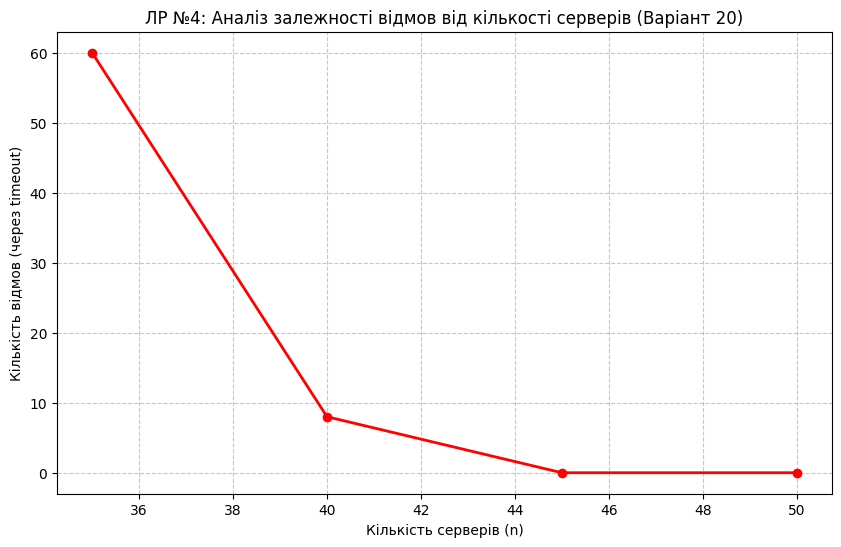

In [ ]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Параметри системи (Варіант 20) ---
LAMBDA_RATE = 4        # Інтенсивність вхідного потоку
MAX_WAIT = 15          # Максимальний час очікування (timeout)
SIM_TIME = 300         # Час моделювання
SERVER_CONFIGS = [35, 40, 45, 50]  # Кількість каналів (n)

TYPES = ['Fast', 'Slow']
PROBS = [0.3, 0.7]     # Ймовірність появи заявок кожного типу
SERVICE_TIMES = {'Fast': 5, 'Slow': 12}

def customer(env, name, servers, ent_type, results):
    """Процес обслуговування клієнта"""
    arrival = env.now
    # Час обслуговування генерується експоненціально
    serv_time = random.expovariate(1.0 / SERVICE_TIMES[ent_type])

    with servers.request() as req:
        # Очікування звільнення сервера або вихід за тайм-аутом
        outcome = yield req | env.timeout(MAX_WAIT)

        wait = env.now - arrival
        if req in outcome:
            # Клієнт дочекався обслуговування
            yield env.timeout(serv_time)
            results['served'] += 1
            results['wait_times'].append(wait)
        else:
            # Клієнт пішов через задовге очікування (відмова)
            results['rejected'] += 1

def source(env, servers, results):
    """Генератор вхідних заявок"""
    i = 0
    while True:
        # Час між надходженнями заявок
        yield env.timeout(random.expovariate(LAMBDA_RATE))
        i += 1
        etype = random.choices(TYPES, weights=PROBS)[0]
        env.process(customer(env, f'C_{i}', servers, etype, results))

# --- Виконання моделювання ---
final_results = {}

for n in SERVER_CONFIGS:

    env = simpy.Environment()
    res = simpy.Resource(env, capacity=n)
    run_stats = {'served': 0, 'rejected': 0, 'wait_times': []}

    env.process(source(env, res, run_stats))
    env.run(until=SIM_TIME)

    avg_w = np.mean(run_stats['wait_times']) if run_stats['wait_times'] else 0
    final_results[n] = (run_stats['served'], run_stats['rejected'], avg_w)

# --- Вивід результатів у консоль ---
print(f"{'Сервери (n)':<12} | {'Обслужено':<10} | {'Відмови':<10} | {'Сер. очікування':<15}")
print("-" * 60)
for n, data in final_results.items():
    print(f"{n:<12} | {data[0]:<10} | {data[1]:<10} | {data[2]:<15.2f}")

# --- Візуалізація ---
n_values = list(final_results.keys())
rejected_values = [data[1] for data in final_results.values()]

plt.figure(figsize=(10, 6))
plt.plot(n_values, rejected_values, marker='o', linestyle='-', color='red', linewidth=2)
plt.title("ЛР №4: Аналіз залежності відмов від кількості серверів (Варіант 20)")
plt.xlabel("Кількість серверів (n)")
plt.ylabel("Кількість відмов (через timeout)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()